# 04 — Spatial Model Integration
## MietOptimal / RentSignal

Retrain XGBoost with all spatial features (OSM + Sentinel-2) added to the original 19 features.

**Goal:** Measure R² improvement from spatial features over the 0.73 baseline.

**Input:** `data/processed/listings_with_spatial.parquet` (10,275 × 45)  
**Output:** Updated model artifacts in `models/` + comparison report

**Three model variants:**
- **Model A** — 19 original features (baseline)
- **Model B** — 19 + 9 OSM spatial features (28 total)
- **Model C** — 19 + 9 OSM + 9 satellite features (37 total)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

MODELS_DIR = Path("../models")
print("Imports loaded")

Imports loaded


## 1. Load data with spatial features

In [3]:
df = pd.read_parquet("../data/processed/listings_with_spatial.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# OSM spatial features
OSM_FEATURES = [
    "dist_transit_m", "dist_park_m", "dist_water_m", "dist_school_m",
    "count_food_500m", "count_shop_500m",
    "count_food_1000m", "count_shop_1000m", "count_transit_1000m",
]

# Sentinel-2 satellite features
SATELLITE_FEATURES = [
    "ndvi_mean", "ndvi_std", "ndvi_median",
    "ndwi_mean", "ndwi_std", "ndwi_median",
    "ndbi_mean", "ndbi_std", "ndbi_median",
]

ALL_SPATIAL = OSM_FEATURES + SATELLITE_FEATURES

# Check coverage
osm_coverage = df[OSM_FEATURES].notna().all(axis=1).sum()
sat_coverage = df[SATELLITE_FEATURES].notna().all(axis=1).sum()
full_coverage = df[ALL_SPATIAL].notna().all(axis=1).sum()

print(f"\nOSM coverage:       {osm_coverage:,}/{len(df):,} ({osm_coverage/len(df)*100:.1f}%)")
print(f"Satellite coverage: {sat_coverage:,}/{len(df):,} ({sat_coverage/len(df)*100:.1f}%)")
print(f"Full coverage:      {full_coverage:,}/{len(df):,} ({full_coverage/len(df)*100:.1f}%)")

# Drop rows without all spatial features
df_spatial = df.dropna(subset=ALL_SPATIAL).copy()
print(f"\nUsing {len(df_spatial):,} listings with complete spatial features")

Loaded: 10,275 rows × 45 columns

OSM coverage:       10,242/10,275 (99.7%)
Satellite coverage: 10,224/10,275 (99.5%)
Full coverage:      10,224/10,275 (99.5%)

Using 10,224 listings with complete spatial features


## 2. Feature preparation

Three model variants for comparison:
- **Model A** — Original 19 features (baseline, same as notebook 02)
- **Model B** — Original 19 + 9 OSM spatial features (28 total)
- **Model C** — Original 19 + 9 OSM + 9 satellite features (37 total)

In [4]:
# Original feature groups (same as notebook 02)
NUMERIC_FEATURES = [
    "livingSpace", "noRooms", "yearConstructed", "floor",
    "numberOfFloors", "thermalChar", "sqm_per_room",
]
BINARY_FEATURES = [
    "balcony", "hasKitchen", "lift", "cellar", "garden", "newlyConst",
]
CATEGORICAL_FEATURES = [
    "condition", "interiorQual", "typeOfFlat", "heatingType",
    "building_era", "bezirk",
]
TARGET = "rent_sqm"

# Prepare data
df_spatial["yearConstructed"] = df_spatial["yearConstructed"].fillna(df_spatial["yearConstructed"].median())

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_spatial[CATEGORICAL_FEATURES] = enc.fit_transform(df_spatial[CATEGORICAL_FEATURES].astype(str))

for col in BINARY_FEATURES:
    df_spatial[col] = df_spatial[col].astype(int)

# Define feature sets
FEATURES_A = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES  # 19 original
FEATURES_B = FEATURES_A + OSM_FEATURES                                   # 19 + 9 = 28
FEATURES_C = FEATURES_A + ALL_SPATIAL                                     # 19 + 18 = 37

y = df_spatial[TARGET]

# Same train/test split for fair comparison
X_a = df_spatial[FEATURES_A]
X_b = df_spatial[FEATURES_B]
X_c = df_spatial[FEATURES_C]

X_train_a, X_test_a, y_train, y_test = train_test_split(X_a, y, test_size=0.2, random_state=42)
X_train_b, X_test_b, _, _ = train_test_split(X_b, y, test_size=0.2, random_state=42)
X_train_c, X_test_c, _, _ = train_test_split(X_c, y, test_size=0.2, random_state=42)

print(f"Model A features: {len(FEATURES_A)} (original)")
print(f"Model B features: {len(FEATURES_B)} (+ OSM)")
print(f"Model C features: {len(FEATURES_C)} (+ OSM + satellite)")
print(f"\nTrain: {len(X_train_a):,} | Test: {len(X_test_a):,}")

Model A features: 19 (original)
Model B features: 28 (+ OSM)
Model C features: 37 (+ OSM + satellite)

Train: 8,179 | Test: 2,045


## 3. Train both models

Using the same hyperparameter grid from notebook 02 for fair comparison.

In [5]:
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [3, 5],
}

xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

# --- Model A: Original features ---
print("Training Model A (19 original features)...")
grid_a = GridSearchCV(xgb_base, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=0, refit=True)
grid_a.fit(X_train_a, y_train)
print(f"  Best CV R²: {grid_a.best_score_:.4f}")

# --- Model B: Original + OSM ---
print("\nTraining Model B (28 features = original + OSM)...")
grid_b = GridSearchCV(xgb_base, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=0, refit=True)
grid_b.fit(X_train_b, y_train)
print(f"  Best CV R²: {grid_b.best_score_:.4f}")

# --- Model C: Original + OSM + Satellite ---
print("\nTraining Model C (37 features = original + OSM + satellite)...")
grid_c = GridSearchCV(xgb_base, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=0, refit=True)
grid_c.fit(X_train_c, y_train)
print(f"  Best CV R²: {grid_c.best_score_:.4f}")

Training Model A (19 original features)...
  Best CV R²: 0.7210

Training Model B (28 features = original + OSM)...
  Best CV R²: 0.7500

Training Model C (37 features = original + OSM + satellite)...
  Best CV R²: 0.7499


## 4. Test set comparison

In [6]:
# Ridge baselines
ridge_a = Ridge(alpha=1.0).fit(X_train_a, y_train)
ridge_b = Ridge(alpha=1.0).fit(X_train_b, y_train)
ridge_c = Ridge(alpha=1.0).fit(X_train_c, y_train)

results = {}
for name, model, X_te in [
    ("Ridge (original)", ridge_a, X_test_a),
    ("Ridge (+ OSM)", ridge_b, X_test_b),
    ("Ridge (+ OSM + sat)", ridge_c, X_test_c),
    ("XGBoost (original)", grid_a.best_estimator_, X_test_a),
    ("XGBoost (+ OSM)", grid_b.best_estimator_, X_test_b),
    ("XGBoost (+ OSM + sat)", grid_c.best_estimator_, X_test_c),
]:
    y_pred = model.predict(X_te)
    results[name] = {
        "R²": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
    }

results_df = pd.DataFrame(results).T
print("=" * 65)
print("MODEL COMPARISON — Test Set")
print("=" * 65)
print(results_df.round(4).to_string())
print("=" * 65)

r2_orig = results["XGBoost (original)"]["R²"]
r2_osm = results["XGBoost (+ OSM)"]["R²"]
r2_full = results["XGBoost (+ OSM + sat)"]["R²"]
rmse_orig = results["XGBoost (original)"]["RMSE"]
rmse_full = results["XGBoost (+ OSM + sat)"]["RMSE"]

print(f"\n--- Improvement Summary ---")
print(f"Original → + OSM:          R² {r2_orig:.4f} → {r2_osm:.4f} ({r2_osm-r2_orig:+.4f})")
print(f"Original → + OSM + sat:    R² {r2_orig:.4f} → {r2_full:.4f} ({r2_full-r2_orig:+.4f})")
print(f"RMSE reduction:            {rmse_orig:.2f} → {rmse_full:.2f} €/m² ({(1-rmse_full/rmse_orig)*100:.1f}% better)")

MODEL COMPARISON — Test Set
                           R²    RMSE     MAE
Ridge (original)       0.3214  4.2635  3.1412
Ridge (+ OSM)          0.4693  3.7705  2.7164
Ridge (+ OSM + sat)    0.4807  3.7298  2.6889
XGBoost (original)     0.7248  2.7150  1.8290
XGBoost (+ OSM)        0.7453  2.6121  1.7232
XGBoost (+ OSM + sat)  0.7491  2.5923  1.7033

--- Improvement Summary ---
Original → + OSM:          R² 0.7248 → 0.7453 (+0.0205)
Original → + OSM + sat:    R² 0.7248 → 0.7491 (+0.0243)
RMSE reduction:            2.72 → 2.59 €/m² (4.5% better)


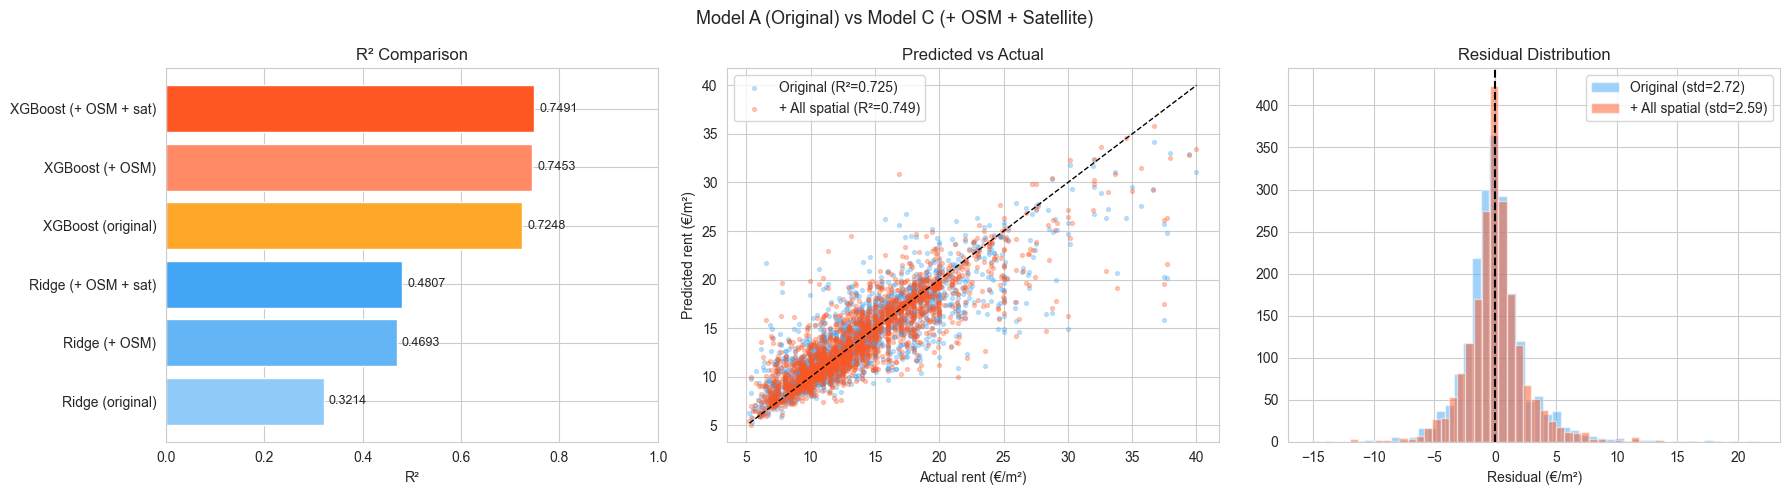

In [7]:
# Visual comparison — all 3 XGBoost variants
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart: R² comparison
ax = axes[0]
models = list(results.keys())
r2_vals = [results[m]["R²"] for m in models]
colors = ["#90CAF9", "#64B5F6", "#42A5F5", "#FFA726", "#FF8A65", "#FF5722"]
ax.barh(models, r2_vals, color=colors)
ax.set_xlabel("R²")
ax.set_title("R² Comparison")
ax.set_xlim(0, 1)
for i, v in enumerate(r2_vals):
    ax.text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)

# Scatter: XGBoost variants
model_a = grid_a.best_estimator_
model_c = grid_c.best_estimator_

ax = axes[1]
ax.scatter(y_test, model_a.predict(X_test_a), alpha=0.3, s=8, color="#42A5F5", label=f"Original (R²={r2_orig:.3f})")
ax.scatter(y_test, model_c.predict(X_test_c), alpha=0.3, s=8, color="#FF5722", label=f"+ All spatial (R²={r2_full:.3f})")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=1)
ax.set_xlabel("Actual rent (€/m²)")
ax.set_ylabel("Predicted rent (€/m²)")
ax.set_title("Predicted vs Actual")
ax.legend()

# Residual comparison
ax = axes[2]
res_a = y_test - model_a.predict(X_test_a)
res_c = y_test - model_c.predict(X_test_c)
ax.hist(res_a, bins=50, alpha=0.5, color="#42A5F5", label=f"Original (std={res_a.std():.2f})")
ax.hist(res_c, bins=50, alpha=0.5, color="#FF5722", label=f"+ All spatial (std={res_c.std():.2f})")
ax.axvline(0, color="black", ls="--")
ax.set_xlabel("Residual (€/m²)")
ax.set_title("Residual Distribution")
ax.legend()

plt.suptitle("Model A (Original) vs Model C (+ OSM + Satellite)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. SHAP analysis — updated with spatial features

See where spatial features rank in the new model's feature importance.

SHAP values computed for 1000 samples


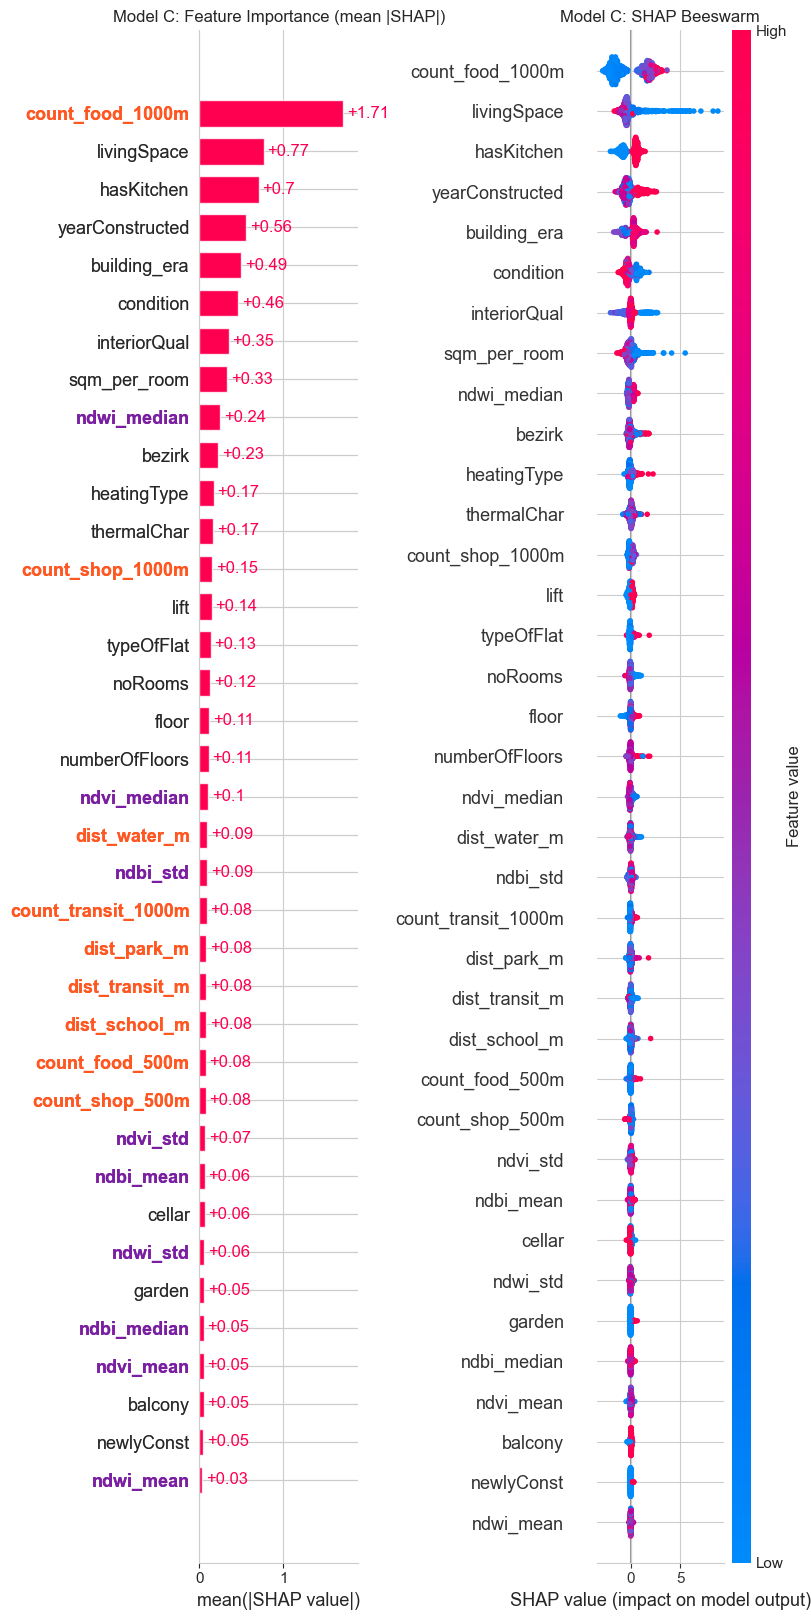


--- Full Feature Rankings ---
  (OSM = orange, SAT = purple)
  # 1 count_food_1000m          1.7117 ← OSM
  # 2 livingSpace               0.7662
  # 3 hasKitchen                0.7050
  # 4 yearConstructed           0.5555
  # 5 building_era              0.4948
  # 6 condition                 0.4575
  # 7 interiorQual              0.3497
  # 8 sqm_per_room              0.3296
  # 9 ndwi_median               0.2445 ← SAT
  #10 bezirk                    0.2258
  #11 heatingType               0.1677
  #12 thermalChar               0.1664
  #13 count_shop_1000m          0.1494 ← OSM
  #14 lift                      0.1435
  #15 typeOfFlat                0.1330
  #16 noRooms                   0.1244
  #17 floor                     0.1139
  #18 numberOfFloors            0.1114
  #19 ndvi_median               0.1046 ← SAT
  #20 dist_water_m              0.0938 ← OSM
  #21 ndbi_std                  0.0895 ← SAT
  #22 count_transit_1000m       0.0847 ← OSM
  #23 dist_park_m               0.0820

In [8]:
# SHAP for Model C (full spatial features)
model_best = grid_c.best_estimator_
explainer_best = shap.TreeExplainer(model_best)
shap_sample = X_test_c.sample(n=min(1000, len(X_test_c)), random_state=42)
shap_values = explainer_best(shap_sample)

print(f"SHAP values computed for {len(shap_sample)} samples")

# Bar plot — highlight spatial features
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

plt.sca(axes[0])
shap.plots.bar(shap_values, max_display=37, show=False)
axes[0].set_title("Model C: Feature Importance (mean |SHAP|)")

# Highlight spatial features
ax = axes[0]
for label in ax.get_yticklabels():
    text = label.get_text()
    if text in OSM_FEATURES:
        label.set_color("#FF5722")
        label.set_fontweight("bold")
    elif text in SATELLITE_FEATURES:
        label.set_color("#7B1FA2")
        label.set_fontweight("bold")

plt.sca(axes[1])
shap.plots.beeswarm(shap_values, max_display=37, show=False)
axes[1].set_title("Model C: SHAP Beeswarm")

plt.tight_layout()
plt.show()

# Print feature rankings
mean_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=FEATURES_C
).sort_values(ascending=False)

print("\n--- Full Feature Rankings ---")
print("  (OSM = orange, SAT = purple)")
for i, (feat, val) in enumerate(mean_shap.items()):
    if feat in OSM_FEATURES:
        marker = " ← OSM"
    elif feat in SATELLITE_FEATURES:
        marker = " ← SAT"
    else:
        marker = ""
    print(f"  #{i+1:2d} {feat:<25s} {val:.4f}{marker}")

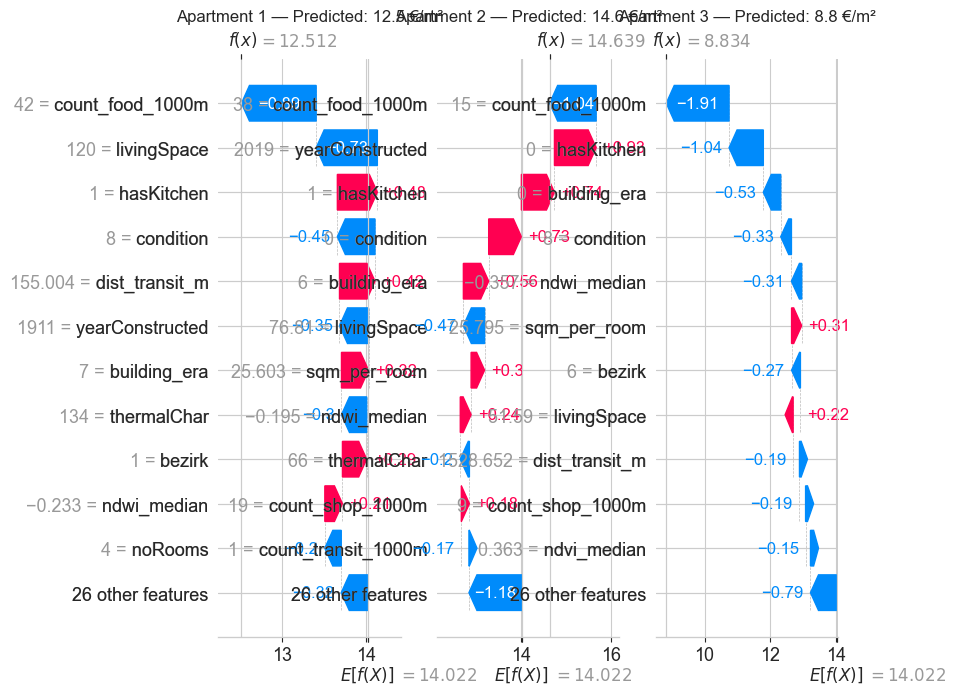

In [9]:
# Waterfall plots for 3 sample apartments — showing all spatial features
fig = plt.figure(figsize=(20, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    shap.plots.waterfall(shap_values[i], max_display=12, show=False)
    pred = model_best.predict(shap_sample.iloc[[i]])[0]
    plt.title(f"Apartment {i+1} — Predicted: {pred:.1f} €/m²")

plt.tight_layout()
plt.show()

## 6. Save updated model artifacts

Save the spatial-augmented model as the new production model.

In [10]:
# Save the best model (Model C with all spatial features)
joblib.dump(model_best, MODELS_DIR / "xgboost_rent.joblib")
joblib.dump(explainer_best, MODELS_DIR / "shap_explainer.joblib")
joblib.dump(enc, MODELS_DIR / "feature_encoder.joblib")

model_config = {
    "target": TARGET,
    "features": FEATURES_C,
    "numeric_features": NUMERIC_FEATURES,
    "binary_features": BINARY_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "osm_features": OSM_FEATURES,
    "satellite_features": SATELLITE_FEATURES,
    "best_params": grid_c.best_params_,
    "train_size": len(X_train_c),
    "test_size": len(X_test_c),
    "metrics": {
        "r2": round(r2_full, 4),
        "rmse": round(results["XGBoost (+ OSM + sat)"]["RMSE"], 4),
        "mae": round(results["XGBoost (+ OSM + sat)"]["MAE"], 4),
    },
    "baseline_metrics": {
        "r2_original": round(r2_orig, 4),
        "r2_osm_only": round(r2_osm, 4),
    },
    "spatial_improvement": {
        "r2_delta_total": round(r2_full - r2_orig, 4),
        "r2_delta_osm": round(r2_osm - r2_orig, 4),
        "r2_delta_satellite": round(r2_full - r2_osm, 4),
        "rmse_reduction_pct": round((1 - rmse_full/rmse_orig) * 100, 1),
    },
}
with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print("Saved updated model artifacts:")
print(f"  models/xgboost_rent.joblib (37 features)")
print(f"  models/shap_explainer.joblib")
print(f"  models/feature_encoder.joblib")
print(f"  models/model_config.json")

Saved updated model artifacts:
  models/xgboost_rent.joblib (37 features)
  models/shap_explainer.joblib
  models/feature_encoder.joblib
  models/model_config.json


In [11]:
# Updated training report
report = f"""# XGBoost Rent Prediction — Training Report (v3: Full Spatial Features)
## Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}

### Dataset
- Source: Kaggle ImmoScout24 (Berlin subset) + OSM + Sentinel-2 spatial features
- Training samples: {len(X_train_c):,}
- Test samples: {len(X_test_c):,}
- Features: {len(FEATURES_C)} (19 original + 9 OSM + 9 satellite)
- Target: rent per m² (baseRent / livingSpace)

### Model Comparison (Test Set)

| Model | R² | RMSE (€/m²) | MAE (€/m²) |
|-------|-----|-------------|------------|
| Ridge (original) | {results['Ridge (original)']['R²']:.4f} | {results['Ridge (original)']['RMSE']:.2f} | {results['Ridge (original)']['MAE']:.2f} |
| Ridge (+ OSM) | {results['Ridge (+ OSM)']['R²']:.4f} | {results['Ridge (+ OSM)']['RMSE']:.2f} | {results['Ridge (+ OSM)']['MAE']:.2f} |
| Ridge (+ OSM + sat) | {results['Ridge (+ OSM + sat)']['R²']:.4f} | {results['Ridge (+ OSM + sat)']['RMSE']:.2f} | {results['Ridge (+ OSM + sat)']['MAE']:.2f} |
| XGBoost (original) | {r2_orig:.4f} | {rmse_orig:.2f} | {results['XGBoost (original)']['MAE']:.2f} |
| XGBoost (+ OSM) | {r2_osm:.4f} | {results['XGBoost (+ OSM)']['RMSE']:.2f} | {results['XGBoost (+ OSM)']['MAE']:.2f} |
| **XGBoost (+ OSM + sat)** | **{r2_full:.4f}** | **{rmse_full:.2f}** | **{results['XGBoost (+ OSM + sat)']['MAE']:.2f}** |

### Spatial Feature Impact
- OSM alone: R² {r2_orig:.4f} → {r2_osm:.4f} ({r2_osm-r2_orig:+.4f})
- OSM + Satellite: R² {r2_orig:.4f} → {r2_full:.4f} ({r2_full-r2_orig:+.4f})
- RMSE: {rmse_orig:.2f} → {rmse_full:.2f} €/m² ({(1-rmse_full/rmse_orig)*100:.1f}% better)

### Spatial Features
**OSM (9):** {', '.join(OSM_FEATURES)}
**Satellite (9):** {', '.join(SATELLITE_FEATURES)}

### Best Hyperparameters
{json.dumps(grid_c.best_params_, indent=2)}

### Notes
- Sentinel-2 scene: 2024-08-20, 0.6% cloud cover (summer composite)
- Spatial features at PLZ centroid level (190 PLZs, 500m buffer for zonal stats)
- Data vintage: 2018-2019 listings
"""

with open(MODELS_DIR / "training_report.md", "w") as f:
    f.write(report)

print(report)

# XGBoost Rent Prediction — Training Report (v3: Full Spatial Features)
## Generated: 2026-03-15 15:48

### Dataset
- Source: Kaggle ImmoScout24 (Berlin subset) + OSM + Sentinel-2 spatial features
- Training samples: 8,179
- Test samples: 2,045
- Features: 37 (19 original + 9 OSM + 9 satellite)
- Target: rent per m² (baseRent / livingSpace)

### Model Comparison (Test Set)

| Model | R² | RMSE (€/m²) | MAE (€/m²) |
|-------|-----|-------------|------------|
| Ridge (original) | 0.3214 | 4.26 | 3.14 |
| Ridge (+ OSM) | 0.4693 | 3.77 | 2.72 |
| Ridge (+ OSM + sat) | 0.4807 | 3.73 | 2.69 |
| XGBoost (original) | 0.7248 | 2.72 | 1.83 |
| XGBoost (+ OSM) | 0.7453 | 2.61 | 1.72 |
| **XGBoost (+ OSM + sat)** | **0.7491** | **2.59** | **1.70** |

### Spatial Feature Impact
- OSM alone: R² 0.7248 → 0.7453 (+0.0205)
- OSM + Satellite: R² 0.7248 → 0.7491 (+0.0243)
- RMSE: 2.72 → 2.59 €/m² (4.5% better)

### Spatial Features
**OSM (9):** dist_transit_m, dist_park_m, dist_water_m, dist_school_m, co